## Model Evaluation — Nigerian Credit Risk Pipeline

### Objective
Deep evaluation of the champion XGBoost model using credit risk specific 
metrics. This notebook goes beyond accuracy to answer the business question:

*"At what threshold should a Nigerian digital lender approve or reject a loan 
application to minimise default risk while maintaining a healthy approval rate?"*

### Evaluation Framework
- **ROC-AUC** — overall discrimination power of the model
- **KS Statistic** — industry standard for credit scorecard validation,
  measures separation between good and bad borrowers
- **Confusion Matrix at multiple thresholds** — shows the business tradeoff 
  between catching defaulters and approving good borrowers
- **Feature Importance** — identifies which borrower signals drive default risk
- **Business Impact** — translates model performance into fintech business metrics

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

In [2]:
# Load best model
model = joblib.load('../models/best_model_xgb.pkl')

# Load features
df = pd.read_csv('../data/features/loan_features.csv')

# Recreate exact same split as notebook 04
numerical = list(df.select_dtypes(include=['int64', 'float64']).columns)
if 'default_flag' in numerical:
    numerical.remove('default_flag')

categorical = list(df.select_dtypes(include=['object', 'str']).columns)

X = df[numerical + categorical]
y = df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Generate predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Test set: {X_test.shape[0]} borrowers")
print(f"Default rate in test set: {y_test.mean():.2%}")
print(f"Best model AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Test set: 11545 borrowers
Default rate in test set: 20.19%
Best model AUC: 0.7223


In [3]:
# calculate the false positive rate, true positive rate and the thresholds using roc_curve from sklearn
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

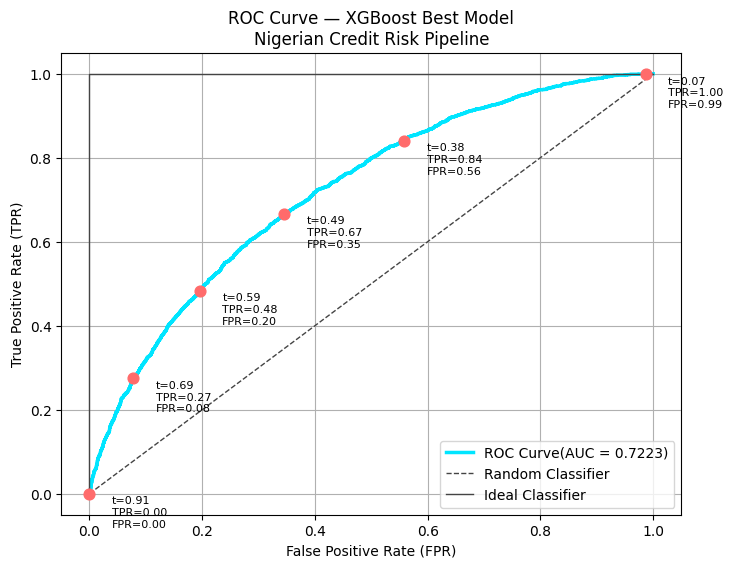


   Threshold     TPR     FPR
--------------------------------
      0.9101  0.0004  0.0000
      0.6913  0.2746  0.0779
      0.5909  0.4835  0.1956
      0.4937  0.6671  0.3460
      0.3849  0.8408  0.5584
      0.0748  1.0000  0.9868


In [4]:
# pick 6 indices to annotate on the curve
num_annotations = 6
annotate_indices = np.linspace(1, len(thresholds) -2, num_annotations, dtype=int)

# create the plot(the ideal classifier, the random classifier and our model classifier)
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(fpr, tpr, color = "#00e5ff", linewidth=2.5, label=f"ROC Curve(AUC = {roc_auc:.4f})")

ax.plot([0,1], [0,1], color = "#444", linestyle = "--", linewidth=1, label = "Random Classifier")

ax.plot([0, 0, 1], [0, 1, 1], color = "#444", linestyle = "-", linewidth=1, label = "Ideal Classifier")

# annotate selected threshold points
for idx in annotate_indices:
    t = thresholds[idx]
    x = fpr[idx]
    y_val = tpr[idx]

    ax.scatter(x, y_val, color = "#ff6b6b", s=60, zorder=5)

    ax.annotate(
        f"t={t:.2f}\nTPR={y_val:.2f}\nFPR={x:.2f}",
        xy=(x,y_val),
        xytext=(x+0.04, y_val-0.08),
        fontsize=8,
    )

# styling
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.grid(True)
plt.title('ROC Curve — XGBoost Best Model\nNigerian Credit Risk Pipeline')
plt.legend()
plt.show()

print(f"\n{'Threshold':>12}{'TPR':>8}{'FPR':>8}")
print("-"*32)

for idx in annotate_indices:
    print(f"{thresholds[idx]:>12.4f}{tpr[idx]:>8.4f}{fpr[idx]:>8.4f}")


### ROC Curve Interpretation

The ROC curve plots the True Positive Rate (defaulters correctly flagged) against 
the False Positive Rate (good borrowers incorrectly flagged) at every possible 
threshold.

**AUC of 0.7223** means the model correctly ranks a randomly chosen defaulter 
above a randomly chosen good borrower 72.23% of the time — significantly better 
than random (50%).

**Key operating points for a Nigerian digital lender:**

| Threshold | Default Catch Rate | False Alarm Rate | Business Interpretation |
|---|---|---|---|
| 0.69 | 27% | 6% | Ultra-conservative — minimal losses, low approval rate |
| 0.49 | 67% | 35% | Balanced — catches majority of defaults, moderate rejections |
| 0.38 | 84% | 56% | Aggressive — maximum default prevention, high rejection rate |

The optimal threshold depends on the lender's **risk appetite** and the relative 
cost of a missed default versus a rejected good borrower.